# EV Battery Failure Risk Prediction & Predictive Maintenance

## Data Science Portfolio Version

This notebook upgrades the original EV battery analysis into a complete supervised machine-learning workflow for predictive maintenance.

### Business question
Can battery, vehicle, charging, driving, maintenance, environmental, and diagnostic signals be used to identify vehicles at elevated risk of battery failure early enough to support predictive-maintenance prioritization?

### Why this is a Data Science problem
The target, `battery_failure`, is binary and the positive class is relatively rare. This makes the task an **imbalanced classification problem** rather than a simple descriptive-analysis exercise.

The workflow therefore focuses on:

- building reproducible preprocessing and modeling pipelines;
- separating training, validation, and test data correctly;
- using metrics that are appropriate for rare-event prediction;
- comparing a linear baseline with a nonlinear tree-based model;
- checking whether engineered composite features materially improve predictive power;
- optimizing the probability threshold for a maintenance decision;
- interpreting predictive drivers without overstating causality.

### Important data disclosure
The dataset is **synthetic**. Its documentation states that it was generated from battery-degradation physics and operational relationships designed to resemble real-world EV behavior. It is appropriate to describe this project as a **simulated EV fleet / manufacturer operations scenario**, but not as real production data from an automaker.


## 1. Technical Stack

**Programming and data processing**
- Python
- pandas
- NumPy

**Machine learning**
- scikit-learn
- XGBoost

**Modeling concepts demonstrated**
- binary classification
- class-imbalance handling
- stratified train / validation / test splitting
- missing-value imputation
- one-hot encoding
- Logistic Regression baseline
- gradient-boosted decision trees
- ablation testing
- PR-AUC and ROC-AUC
- precision / recall / F1
- threshold optimization
- feature importance

**Visualization**
- Matplotlib


In [1]:
# Core libraries used throughout the workflow
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_recall_fscore_support,
    confusion_matrix,
    precision_recall_curve,
)
from xgboost import XGBClassifier

RANDOM_STATE = 42
DATA_PATH = "ev_battery_failure_dataset.csv"


## 2. Load and Audit the Dataset

The first step is to verify the structure of the data, inspect the target distribution, and identify columns that should not be used as predictive signals.

Two identifier columns, `vehicle_id` and `battery_serial`, are excluded from modeling because they identify records rather than describe operational battery behavior.


In [2]:
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("\nTarget counts:")
print(df["battery_failure"].value_counts())
print("\nTarget proportions:")
print(df["battery_failure"].value_counts(normalize=True))

df.head()


Dataset shape: (200000, 70)

Target counts:
battery_failure
0    180079
1     19921
Name: count, dtype: int64

Target proportions:
battery_failure
0    0.900395
1    0.099605
Name: proportion, dtype: float64


,vehicle_id,vehicle_brand,vehicle_model,vehicle_type,manufacturing_year,battery_manufacturer,battery_chemistry,battery_capacity_kwh,drive_type,odometer_km,vehicle_age_years,fleet_or_private,battery_serial,cycle_count,battery_health_percent,state_of_charge,depth_of_discharge,state_of_health,cell_voltage_avg,cell_voltage_std,pack_voltage,cell_temperature_avg,cell_temperature_max,internal_resistance,charge_efficiency,discharge_efficiency,remaining_capacity,capacity_loss_percent,charging_cycles_last_month,fast_charge_ratio,slow_charge_ratio,average_charge_power_kw,average_charging_time,overnight_charging_ratio,home_charging_ratio,charging_interruptions,overcharge_events,average_speed,average_trip_distance,aggressive_acceleration_score,hard_braking_score,regenerative_braking_usage,highway_driving_ratio,city_driving_ratio,daily_distance,average_ambient_temperature,maximum_temperature,minimum_temperature,humidity,altitude,terrain_type,dust_exposure,last_service_days,cooling_system_health,firmware_updates,previous_faults,maintenance_score,thermal_runaway_risk,voltage_imbalance,temperature_variance,sensor_fault_count,BMS_warning_count,abnormal_voltage_events,battery_stress_index,aging_score,thermal_health_score,charging_quality_score,driving_stress_score,predicted_remaining_life_cycles,battery_failure
0,EV100000,Nissan,Leaf,SUV,2019.0,CATL,LMO,82.54,RWD,98163.0,6.94,Private,BAT-91869505,250.0,73.61,85.23,26.34,72.93,NaN,0.01829,934.42,-15.66,-10.04,0.6585,94.63,80.08,60.76,26.39,4.0,0.206,0.797,25.46,212.2,0.543,0.675,0.0,2.0,58.0,38.7,0.0,7.0,69.4,0.352,0.676,50.6,-14.3,-5.9,-21.5,100.0,400.2,NaN,20.4,159.0,79.3,2.0,0.0,94.8,48.7,15.30,5.28,2.0,3.0,0.0,0.0,53.5,66.0,65.2,0.0,401.0,0
1,EV100001,Audi,e-tron,Sedan,2018.0,Samsung SDI,NaN,64.17,AWD,113600.0,7.79,Private,BAT-67968204,256.0,85.77,49.12,44.83,86.71,3.3658,0.01518,841.46,NaN,34.30,0.5206,95.16,94.95,55.04,14.23,3.0,0.417,0.543,55.83,68.5,NaN,0.708,0.0,2.0,30.7,29.4,36.3,33.1,80.7,0.353,0.661,50.6,26.4,44.6,18.8,72.9,702.7,Hilly,15.7,193.0,73.3,3.0,0.0,100.0,48.6,9.42,7.19,0.0,3.0,0.0,51.0,38.8,67.8,46.3,40.9,1094.0,0
2,EV100002,Toyota,bZ4X,Van,2018.0,Guoxuan,NMC,90.92,RWD,242253.0,7.85,Fleet,BAT-82263437,556.0,72.37,NaN,33.65,72.17,3.4152,NaN,853.81,16.83,31.37,0.6135,92.21,88.87,65.80,27.63,7.0,0.624,0.379,55.38,120.5,0.416,0.449,0.0,2.0,60.5,40.0,27.6,9.8,71.0,0.374,0.623,101.3,9.5,13.0,2.4,57.8,687.4,Flat,22.9,193.0,73.8,3.0,1.0,72.2,53.2,18.86,20.75,4.0,1.0,0.0,36.2,66.1,48.6,0.0,6.5,645.0,0
3,EV100003,Volkswagen,ID.3,Hatchback,2022.0,CATL,NMC,47.35,AWD,83700.0,NaN,Private,BAT-92487292,353.0,85.11,54.32,37.73,NaN,3.4202,0.01518,739.43,-1.10,6.25,0.4144,94.26,84.69,40.30,14.89,10.0,0.417,0.559,39.19,83.3,0.336,0.760,0.0,0.0,65.6,29.9,12.8,10.1,68.2,0.379,0.599,58.2,-4.2,2.0,-22.5,47.3,752.2,Hilly,59.0,60.0,88.3,0.0,0.0,95.4,53.6,12.99,9.04,0.0,3.0,1.0,23.4,32.5,58.2,NaN,NaN,867.0,0
4,EV100004,Tesla,Model X,Crossover,2015.0,BYD Battery,NMC,68.04,FWD,88784.0,11.13,Private,BAT-99314176,287.0,87.40,62.73,65.29,86.17,3.4556,0.02111,863.90,29.71,31.20,0.5663,96.60,93.78,59.47,12.60,5.0,0.250,0.755,44.07,118.2,0.454,0.586,0.0,0.0,61.6,8.1,61.0,35.4,34.2,0.000,1.000,27.5,NaN,29.8,10.3,30.6,283.6,Coastal,33.9,NaN,48.2,19.0,3.0,100.0,62.1,25.29,10.55,3.0,2.0,1.0,51.2,45.4,51.0,NaN,100.0,1090.0,0


### Dataset profile

The code above reports the dataset size and observed failure rate directly from the loaded data. Keeping these values in executable output avoids inconsistencies if the dataset is regenerated or the notebook is run in a different environment.

Because the positive class is much smaller than the negative class, raw accuracy would be misleading. A model could predict "no failure" for almost every record and still appear accurate.

For this reason, the primary ranking metric is **PR-AUC (Precision–Recall Area Under the Curve)**. ROC-AUC is also reported, but PR-AUC is particularly informative when the positive class is uncommon.

In [3]:
# Review missingness before defining the preprocessing strategy
missing_rate = (
    df.isna()
      .mean()
      .sort_values(ascending=False)
      .rename("missing_rate")
)

missing_rate.head(15)


fast_charge_ratio         0.049395
average_speed             0.049245
manufacturing_year        0.049145
home_charging_ratio       0.049025
sensor_fault_count        0.048370
charging_interruptions    0.048240
state_of_charge           0.048180
state_of_health           0.047825
capacity_loss_percent     0.047795
slow_charge_ratio         0.047415
cell_temperature_max      0.047250
cooling_system_health     0.047040
cell_voltage_avg          0.046990
charge_efficiency         0.046525
hard_braking_score        0.046195
Name: missing_rate, dtype: float64

## 3. Feature Design and Leakage-Aware Ablation

The dataset already contains several engineered composite variables:

- `battery_stress_index`
- `aging_score`
- `thermal_health_score`
- `charging_quality_score`
- `driving_stress_score`
- `predicted_remaining_life_cycles`

Because the dataset is synthetic, some engineered variables may sit closer to the target-generation logic than ordinary raw telemetry. Using them is not automatically invalid, but a rigorous workflow should test how dependent the model is on them.

Therefore, two feature sets are created:

### Model A — Raw / operational features
Identifiers and the six engineered composite variables are excluded.

### Model B — All non-ID features
Identifiers are excluded, but the engineered composite variables are retained.

This comparison is an **ablation test**. It answers a more useful question than simply asking which model has the highest score:

> How much predictive performance is added by the engineered composite features beyond the underlying operational telemetry?


In [4]:
TARGET = "battery_failure"
ID_COLS = ["vehicle_id", "battery_serial"]

ENGINEERED_COLS = [
    "battery_stress_index",
    "aging_score",
    "thermal_health_score",
    "charging_quality_score",
    "driving_stress_score",
    "predicted_remaining_life_cycles",
]

X = df.drop(columns=[TARGET])
y = df[TARGET].astype(int)

RAW_COLS = [
    column for column in X.columns
    if column not in ID_COLS + ENGINEERED_COLS
]

ALL_COLS = [
    column for column in X.columns
    if column not in ID_COLS
]

print("Raw / operational feature count:", len(RAW_COLS))
print("All non-ID feature count:", len(ALL_COLS))


Raw / operational feature count: 61
All non-ID feature count: 67


## 4. Train / Validation / Test Strategy

A three-way split is used:

- **70% training set** — fit model parameters;
- **15% validation set** — choose the business probability threshold;
- **15% test set** — evaluate the final model once after model and threshold decisions are made.

The split is **stratified** so that the battery-failure rate remains approximately consistent across all three partitions.

This separation is important because selecting a threshold directly on the test set would leak information from the final evaluation data into the modeling process.


In [5]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE,
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE,
)

split_summary = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Rows": [len(y_train), len(y_val), len(y_test)],
    "Failure Rate": [y_train.mean(), y_val.mean(), y_test.mean()],
})

split_summary


,Split,Rows,Failure Rate
0,Train,140000,0.099607
1,Validation,30000,0.099600
2,Test,30000,0.099600


## 5. Preprocessing Pipeline

Preprocessing is handled inside reproducible transformation pipelines.

### Numeric features
- Missing values are filled with the training-set median.
- Standardization is used for Logistic Regression because it is a linear model whose coefficients can be sensitive to scale.

### Categorical features
- Missing values are filled with the most frequent training-set category.
- One-hot encoding converts categories into machine-readable indicator columns.
- Unknown categories are ignored at inference time so that the pipeline remains robust.

The preprocessor is fit **only on the training data** and then applied to validation and test data. This prevents information leakage from later splits.


In [6]:
def make_preprocessor(frame, scale_numeric=False):
    # Detect categorical columns by asking whether each column is numeric.
    # This is more robust than checking dtype == "object" because pandas 3
    # may store text columns using a dedicated string dtype.
    categorical_columns = [
        column for column in frame.columns
        if not pd.api.types.is_numeric_dtype(frame[column])
    ]

    numeric_columns = [
        column for column in frame.columns
        if column not in categorical_columns
    ]

    numeric_steps = [
        ("imputer", SimpleImputer(strategy="median"))
    ]

    if scale_numeric:
        # Centering and scaling are used for Logistic Regression so optimization
        # is numerically stable and coefficients are not dominated by variables
        # measured on larger numerical scales.
        numeric_steps.append(
            ("scaler", StandardScaler())
        )

    numeric_pipeline = Pipeline(numeric_steps)

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True,
            ),
        ),
    ])

    return ColumnTransformer([
        ("num", numeric_pipeline, numeric_columns),
        ("cat", categorical_pipeline, categorical_columns),
    ])

## 6. Evaluation Metrics

No single metric is sufficient for this problem.

- **PR-AUC:** primary ranking metric for an imbalanced positive class.
- **ROC-AUC:** overall discrimination across thresholds.
- **Recall:** proportion of actual failures detected.
- **Precision:** proportion of predicted failures that are truly failures.
- **F1:** balance between precision and recall.
- **Confusion matrix:** operational count of true positives, false positives, true negatives, and false negatives.

In a predictive-maintenance setting, missing a truly high-risk battery may be costly. Therefore, the final decision threshold is chosen to preserve high recall rather than automatically using the default 0.50 cutoff.


In [7]:
def evaluate_probabilities(y_true, probability, threshold=0.50):
    prediction = (probability >= threshold).astype(int)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        prediction,
        average="binary",
        zero_division=0,
    )

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        prediction,
    ).ravel()

    return pd.Series({
        "PR_AUC": average_precision_score(y_true, probability),
        "ROC_AUC": roc_auc_score(y_true, probability),
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Threshold": threshold,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
    })


## 7. Baseline Models

A strong predictive model should be compared with simpler alternatives.

### Dummy baseline
The dummy classifier provides a no-skill reference based on the observed class prevalence.

### Logistic Regression
Logistic Regression is an interpretable linear baseline. It tests whether battery-failure risk can already be modeled well through additive linear effects.

### XGBoost
XGBoost is used because battery-failure risk can involve nonlinear relationships and interactions among thermal conditions, degradation, charging behavior, usage, maintenance, and diagnostic signals.

The goal is not to use a complex model for its own sake. The purpose is to test whether nonlinear structure materially improves prediction over simpler baselines.


In [8]:
# Dummy baseline
# This model intentionally contains no predictive signal.
dummy = DummyClassifier(strategy="prior")
dummy.fit(np.zeros((len(y_train), 1)), y_train)

dummy_probability = dummy.predict_proba(
    np.zeros((len(y_test), 1))
)[:, 1]

dummy_result = evaluate_probabilities(
    y_test,
    dummy_probability,
    threshold=0.50,
)

dummy_result


PR_AUC           0.0996
ROC_AUC          0.5000
Precision        0.0000
Recall           0.0000
F1               0.0000
Threshold        0.5000
TN           27012.0000
FP               0.0000
FN            2988.0000
TP               0.0000
dtype: float64

In [9]:
# Logistic Regression on raw / operational features
# The raw feature set is used to create an interpretable linear baseline
# before testing whether a more complex nonlinear model adds material value.
logit_preprocessor = make_preprocessor(
    X_train[RAW_COLS],
    scale_numeric=True,
)

X_train_logit = logit_preprocessor.fit_transform(
    X_train[RAW_COLS]
)
X_test_logit = logit_preprocessor.transform(
    X_test[RAW_COLS]
)

# lbfgs is used with centered and scaled numeric features for stable optimization.
logit = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    solver="lbfgs",
    random_state=RANDOM_STATE,
)

logit.fit(X_train_logit, y_train)

logit_probability = logit.predict_proba(
    X_test_logit
)[:, 1]

logit_result = evaluate_probabilities(
    y_test,
    logit_probability,
    threshold=0.50,
)

logit_result

PR_AUC           0.917244
ROC_AUC          0.988687
Precision        0.630892
Recall           0.954150
F1               0.759558
Threshold        0.500000
TN           25344.000000
FP            1668.000000
FN             137.000000
TP            2851.000000
dtype: float64

## 8. Imbalance-Aware XGBoost

The training data contain far more healthy batteries than failures.

Instead of changing the validation or test distributions, XGBoost uses `scale_pos_weight` during training. This increases the loss contribution of positive failure cases.

The weight is calculated approximately as:

> number of negative training cases / number of positive training cases

This approach helps the model pay more attention to the minority class while preserving the real class distribution in validation and test data.


In [10]:
scale_pos_weight = (
    (len(y_train) - y_train.sum()) / y_train.sum()
)

print("scale_pos_weight:", scale_pos_weight)

xgb_params = dict(
    n_estimators=350,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_lambda=2.0,
    min_child_weight=3,
    objective="binary:logistic",
    eval_metric="aucpr",
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    n_jobs=4,
    tree_method="hist",
    importance_type="gain",
)


scale_pos_weight: 9.039440659734671


## 9. XGBoost Model A — Raw / Operational Features

This model intentionally excludes the six pre-engineered composite scores.

The purpose is to test whether the underlying telemetry and operational variables alone contain enough predictive signal to identify battery-failure risk.


In [11]:
raw_preprocessor = make_preprocessor(
    X_train[RAW_COLS],
    scale_numeric=False,
)

X_train_raw = raw_preprocessor.fit_transform(
    X_train[RAW_COLS]
)
X_val_raw = raw_preprocessor.transform(
    X_val[RAW_COLS]
)
X_test_raw = raw_preprocessor.transform(
    X_test[RAW_COLS]
)

xgb_raw = XGBClassifier(**xgb_params)

xgb_raw.fit(
    X_train_raw,
    y_train,
    eval_set=[(X_val_raw, y_val)],
    verbose=False,
)

raw_test_probability = xgb_raw.predict_proba(
    X_test_raw
)[:, 1]

xgb_raw_result = evaluate_probabilities(
    y_test,
    raw_test_probability,
    threshold=0.50,
)

xgb_raw_result


PR_AUC           0.919227
ROC_AUC          0.988789
Precision        0.657448
Recall           0.946787
F1               0.776025
Threshold        0.500000
TN           25538.000000
FP            1474.000000
FN             159.000000
TP            2829.000000
dtype: float64

## 10. XGBoost Model B — All Non-ID Features

The second XGBoost model includes the engineered composite scores in addition to the underlying operational variables.

Comparing this model with Model A creates an ablation study:

> If performance improves only slightly, the raw operational variables already contain most of the useful signal.

> If performance improves substantially, the engineered features are adding important predictive structure.


In [12]:
all_preprocessor = make_preprocessor(
    X_train[ALL_COLS],
    scale_numeric=False,
)

X_train_all = all_preprocessor.fit_transform(
    X_train[ALL_COLS]
)
X_val_all = all_preprocessor.transform(
    X_val[ALL_COLS]
)
X_test_all = all_preprocessor.transform(
    X_test[ALL_COLS]
)

xgb_all = XGBClassifier(**xgb_params)

xgb_all.fit(
    X_train_all,
    y_train,
    eval_set=[(X_val_all, y_val)],
    verbose=False,
)

all_validation_probability = xgb_all.predict_proba(
    X_val_all
)[:, 1]

all_test_probability = xgb_all.predict_proba(
    X_test_all
)[:, 1]

xgb_all_default_result = evaluate_probabilities(
    y_test,
    all_test_probability,
    threshold=0.50,
)

xgb_all_default_result


PR_AUC           0.924378
ROC_AUC          0.989650
Precision        0.667449
Recall           0.951807
F1               0.784660
Threshold        0.500000
TN           25595.000000
FP            1417.000000
FN             144.000000
TP            2844.000000
dtype: float64

## 11. Model Comparison

The table below is generated from the current run and should be treated as the source of truth for model performance. This avoids embedding version-sensitive model scores directly in narrative text.

The key comparison is not simply whether XGBoost wins. It is whether the nonlinear model adds enough predictive value to justify its additional complexity relative to Logistic Regression. In this project, the linear baseline is already very strong, so any XGBoost improvement should be described as **incremental rather than dramatic**.

In [13]:
comparison = pd.DataFrame({
    "Model": [
        "Dummy baseline",
        "Logistic Regression — raw features",
        "XGBoost — raw / operational features",
        "XGBoost — all non-ID features",
    ],
    "PR_AUC": [
        dummy_result["PR_AUC"],
        logit_result["PR_AUC"],
        xgb_raw_result["PR_AUC"],
        xgb_all_default_result["PR_AUC"],
    ],
    "ROC_AUC": [
        dummy_result["ROC_AUC"],
        logit_result["ROC_AUC"],
        xgb_raw_result["ROC_AUC"],
        xgb_all_default_result["ROC_AUC"],
    ],
    "Precision": [
        dummy_result["Precision"],
        logit_result["Precision"],
        xgb_raw_result["Precision"],
        xgb_all_default_result["Precision"],
    ],
    "Recall": [
        dummy_result["Recall"],
        logit_result["Recall"],
        xgb_raw_result["Recall"],
        xgb_all_default_result["Recall"],
    ],
    "F1": [
        dummy_result["F1"],
        logit_result["F1"],
        xgb_raw_result["F1"],
        xgb_all_default_result["F1"],
    ],
})

display(comparison.style.format({
    "PR_AUC": "{:.3f}",
    "ROC_AUC": "{:.3f}",
    "Precision": "{:.3f}",
    "Recall": "{:.3f}",
    "F1": "{:.3f}",
}))

logit_pr = float(logit_result["PR_AUC"])
raw_xgb_pr = float(xgb_raw_result["PR_AUC"])
all_xgb_pr = float(xgb_all_default_result["PR_AUC"])

print(f"Logistic Regression PR-AUC: {logit_pr:.3f}")
print(f"Raw-feature XGBoost PR-AUC: {raw_xgb_pr:.3f}")
print(f"All-feature XGBoost PR-AUC: {all_xgb_pr:.3f}")
print(f"XGBoost lift over Logistic Regression (raw features): {raw_xgb_pr - logit_pr:+.3f}")
print(f"Engineered-feature lift within XGBoost: {all_xgb_pr - raw_xgb_pr:+.3f}")

,Model,PR_AUC,ROC_AUC,Precision,Recall,F1
0,Dummy baseline,0.100,0.500,0.000,0.000,0.000
1,Logistic Regression — raw features,0.917,0.989,0.631,0.954,0.760
2,XGBoost — raw / operational features,0.919,0.989,0.657,0.947,0.776
3,XGBoost — all non-ID features,0.924,0.990,0.667,0.952,0.785


Logistic Regression PR-AUC: 0.917
Raw-feature XGBoost PR-AUC: 0.919
All-feature XGBoost PR-AUC: 0.924
XGBoost lift over Logistic Regression (raw features): +0.002
Engineered-feature lift within XGBoost: +0.005


## 12. Business Threshold Optimization

Machine-learning classifiers return probabilities, not business decisions.

Using a default threshold of 0.50 is arbitrary unless the costs of false positives and false negatives are symmetric.

For predictive maintenance, a missed failure can be more costly than an unnecessary inspection. Therefore, the validation set is used to choose the **highest-precision threshold that still achieves at least 90% recall**.

The threshold is selected on validation data only. The test set remains untouched until the final evaluation.


In [14]:
def select_threshold_for_recall(
    y_true,
    probability,
    target_recall=0.90,
):
    precision, recall, thresholds = precision_recall_curve(
        y_true,
        probability,
    )

    feasible = []

    for index, threshold in enumerate(thresholds):
        if recall[index] >= target_recall:
            feasible.append(
                (
                    precision[index],
                    recall[index],
                    float(threshold),
                )
            )

    if not feasible:
        raise ValueError(
            "No threshold satisfies the requested recall target."
        )

    return max(feasible, key=lambda row: row[0])

validation_precision, validation_recall, business_threshold = (
    select_threshold_for_recall(
        y_val,
        all_validation_probability,
        target_recall=0.90,
    )
)

print("Selected threshold:", business_threshold)
print("Validation precision:", validation_precision)
print("Validation recall:", validation_recall)


Selected threshold: 0.7126731276512146
Validation precision: 0.7447397563676633
Validation recall: 0.9002677376171352


In [15]:
business_result = evaluate_probabilities(
    y_test,
    all_test_probability,
    threshold=business_threshold,
)

business_result


PR_AUC           0.924378
ROC_AUC          0.989650
Precision        0.759295
Recall           0.908969
F1               0.827418
Threshold        0.712673
TN           26151.000000
FP             861.000000
FN             272.000000
TP            2716.000000
dtype: float64

In [16]:
from IPython.display import Markdown, display

display(Markdown(f"""
### Business-threshold result from this run

The validation procedure selected a threshold of approximately **{business_threshold:.3f}**.

On the untouched test set, the threshold achieved:

- **Recall:** {float(business_result['Recall']):.1%}
- **Precision:** {float(business_result['Precision']):.1%}
- **F1:** {float(business_result['F1']):.3f}
- **False negatives:** {int(business_result['FN']):,}
- **False positives:** {int(business_result['FP']):,}

This threshold is more meaningful for a predictive-maintenance use case than an automatic 0.50 cutoff because it explicitly prioritizes detection of high-risk batteries.

The threshold is an analytical decision rule for this simulated project, not a production maintenance policy.
"""))


### Business-threshold result from this run

The validation procedure selected a threshold of approximately **0.713**.

On the untouched test set, the threshold achieved:

- **Recall:** 90.9%
- **Precision:** 75.9%
- **F1:** 0.827
- **False negatives:** 272
- **False positives:** 861

This threshold is more meaningful for a predictive-maintenance use case than an automatic 0.50 cutoff because it explicitly prioritizes detection of high-risk batteries.

The threshold is an analytical decision rule for this simulated project, not a production maintenance policy.


## 13. Precision–Recall Curve

The Precision–Recall curve shows the trade-off between detecting more true failures and generating more false maintenance alerts.

This visualization is particularly useful in an imbalanced problem because different maintenance organizations may choose different operating points depending on inspection capacity and the relative cost of missed failures.


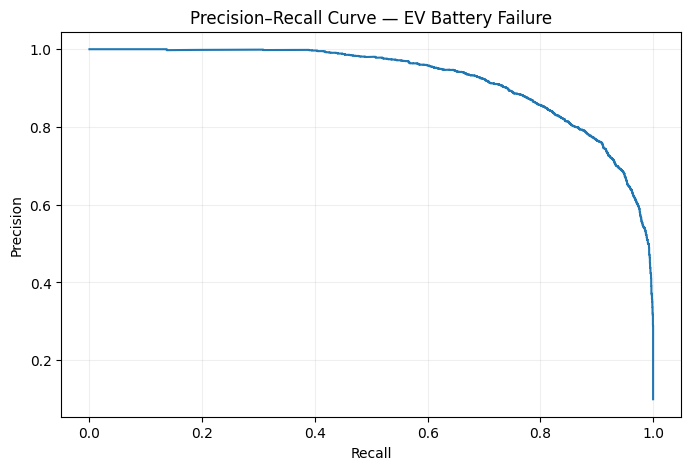

In [17]:
precision, recall, thresholds = precision_recall_curve(
    y_test,
    all_test_probability,
)

plt.figure(figsize=(8, 5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve — EV Battery Failure")
plt.grid(alpha=0.2)
plt.show()


## 14. Feature Importance

The final XGBoost model is inspected using gain-based feature importance.

Feature importance is used here as a **predictive explanation**, not as a causal claim. A highly ranked variable helps the model distinguish higher-risk from lower-risk observations, but it does not prove that changing that variable would directly cause battery-failure risk to change.


In [18]:
feature_names = all_preprocessor.get_feature_names_out()

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": xgb_all.feature_importances_,
})

feature_importance["feature"] = (
    feature_importance["feature"]
    .str.replace(r"^(num__|cat__)", "", regex=True)
)

top_features = (
    feature_importance
    .sort_values("importance", ascending=False)
    .head(15)
)

top_features


,feature,importance
5,battery_health_percent,0.278930
18,capacity_loss_percent,0.260642
10,cell_voltage_std,0.083663
8,state_of_health,0.048180
54,aging_score,0.030180
56,charging_quality_score,0.019806
48,voltage_imbalance,0.015268
53,battery_stress_index,0.013883
51,BMS_warning_count,0.010351
13,cell_temperature_max,0.009769


### Redundancy check among top battery-health features

Feature importance can be misleading when several predictors encode nearly the same underlying signal. In this dataset, `battery_health_percent`, `capacity_loss_percent`, and `state_of_health` are strongly overlapping battery-health measures.

The correlation check below makes that redundancy explicit. When highly correlated variables are used together in tree models, gain-based importance may be split across them or assigned unevenly. Therefore, these rankings should be interpreted as evidence that **battery-health state is important**, not as proof that one of these near-duplicate variables is uniquely dominant.

A production modeling workflow could remove one or more redundant variables or compare performance after feature consolidation. For this portfolio analysis, the variables are retained so the notebook can demonstrate the issue transparently rather than hide it.

In [19]:
redundant_health_features = [
    "battery_health_percent",
    "capacity_loss_percent",
    "state_of_health",
]

health_feature_correlation = (
    df[redundant_health_features]
    .corr()
    .round(3)
)

health_feature_correlation

,battery_health_percent,capacity_loss_percent,state_of_health
battery_health_percent,1.000,-1.000,0.994
capacity_loss_percent,-1.000,1.000,-0.994
state_of_health,0.994,-0.994,1.000


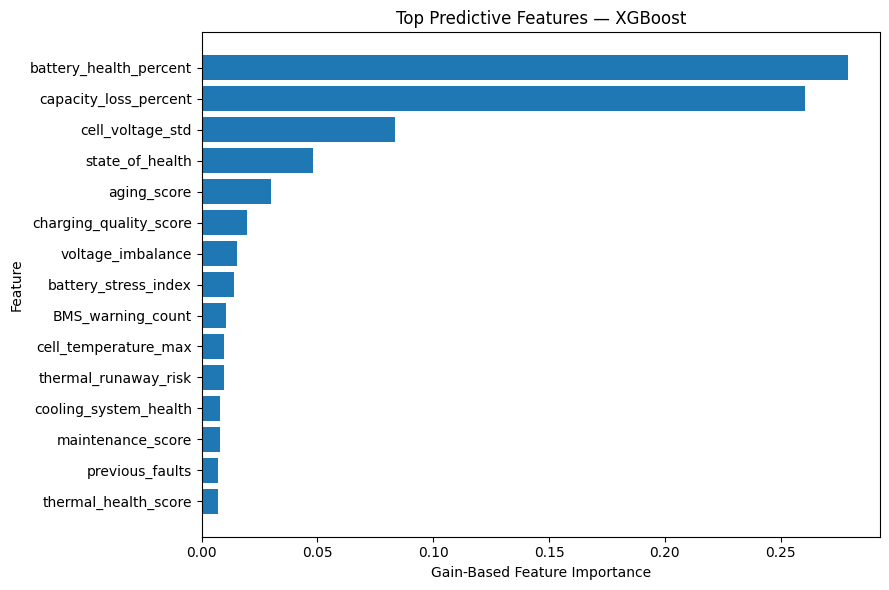

In [20]:
plot_data = top_features.sort_values(
    "importance",
    ascending=True,
)

plt.figure(figsize=(9, 6))
plt.barh(
    plot_data["feature"],
    plot_data["importance"],
)
plt.xlabel("Gain-Based Feature Importance")
plt.ylabel("Feature")
plt.title("Top Predictive Features — XGBoost")
plt.tight_layout()
plt.show()


## 15. Final Data Science Interpretation

This project demonstrates a complete predictive-maintenance modeling workflow rather than a single-model exercise.

### What the analysis shows
1. The target is imbalanced, so PR-AUC and recall are more informative than raw accuracy.
2. Logistic Regression is a strong baseline, which indicates that much of the predictive signal is approximately linear or additive after preprocessing.
3. XGBoost provides only an incremental improvement over the linear baseline, so the project does **not** claim that complex nonlinear structure is the dominant source of predictive performance.
4. Raw operational features already contain most of the available predictive signal.
5. Engineered composite variables add only a modest improvement, which is useful evidence that the model is not entirely dependent on precomputed risk scores.
6. Probability thresholds should be selected according to the business cost of false positives and false negatives rather than using 0.50 by default.
7. Feature importance supports predictive interpretation, but correlated battery-health variables share the same underlying signal and should not be treated as independent causal drivers.

### Data Science concepts demonstrated
- supervised machine learning;
- rare-event / imbalanced classification;
- stratified train / validation / test splitting;
- leakage-aware feature design;
- preprocessing pipelines;
- interpretable linear baselines;
- gradient-boosted tree comparison;
- PR-AUC and ROC-AUC evaluation;
- precision / recall trade-offs;
- ablation testing;
- threshold optimization;
- multicollinearity / redundancy awareness in interpretation;
- predictive explainability;
- business-oriented model interpretation.

### Important limitation
The dataset is synthetic. Strong predictive results validate the modeling workflow on realistically structured simulated telemetry; they should **not** be presented as production performance from a real automaker.

### Safe portfolio description
> Built an EV battery failure-risk model on 200K simulated fleet telemetry records designed to reflect real-world degradation and operating conditions, comparing Logistic Regression and XGBoost, evaluating imbalanced-class performance with PR-AUC, and optimizing a maintenance threshold for high recall.
